# Teleportation Protocol
The teleportation protocol is a quantum communication protocol that allows for the transfer of quantum information from one location to another without physically moving the quantum state. This is achieved through the use of entanglement and classical communication.

In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.result import marginal_distribution
from qiskit.circuit.library import UGate
from math import pi
import random

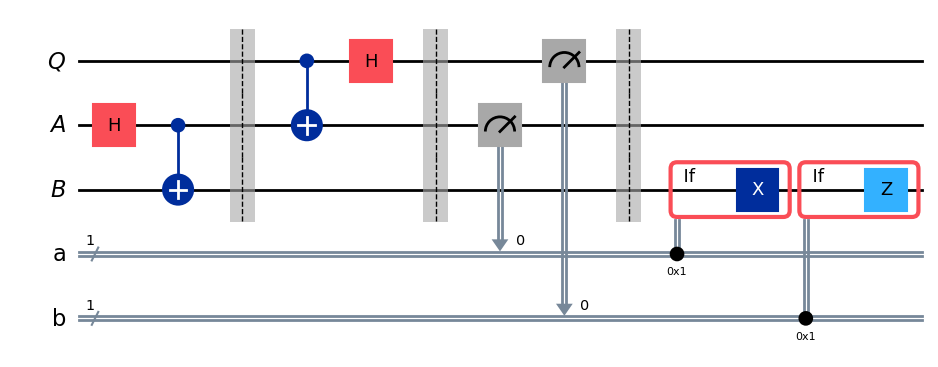

In [2]:
# quantum registers default to ket0
qubit = QuantumRegister(size=1, name='Q') # the actual qubit we want to teleport
ebit0 = QuantumRegister(1, 'A')
ebit1 = QuantumRegister(1, 'B')
a = ClassicalRegister(1, 'a')
b = ClassicalRegister(1, 'b')

protocol = QuantumCircuit(qubit, ebit0, ebit1, a, b)

# converts A and B into |Phi+> state
# not actually part of the protocol itself, but needed to properly entangle the qubits
protocol.h(ebit0)
protocol.cx(control_qubit=ebit0, target_qubit=ebit1)
protocol.barrier() # avoids optimization across this point to maintain the structure of the circuit for demo

protocol.cx(control_qubit=qubit, target_qubit=ebit0)
protocol.h(qubit)
protocol.barrier()

protocol.measure(qubit=ebit0, cbit=a)
protocol.measure(qubit=qubit, cbit=b)
protocol.barrier()

with protocol.if_test((a, 1)):
    protocol.x(ebit1)
with protocol.if_test((b, 1)):
    protocol.z(ebit1)

display(protocol.draw('mpl'))

<IPython.core.display.Latex object>

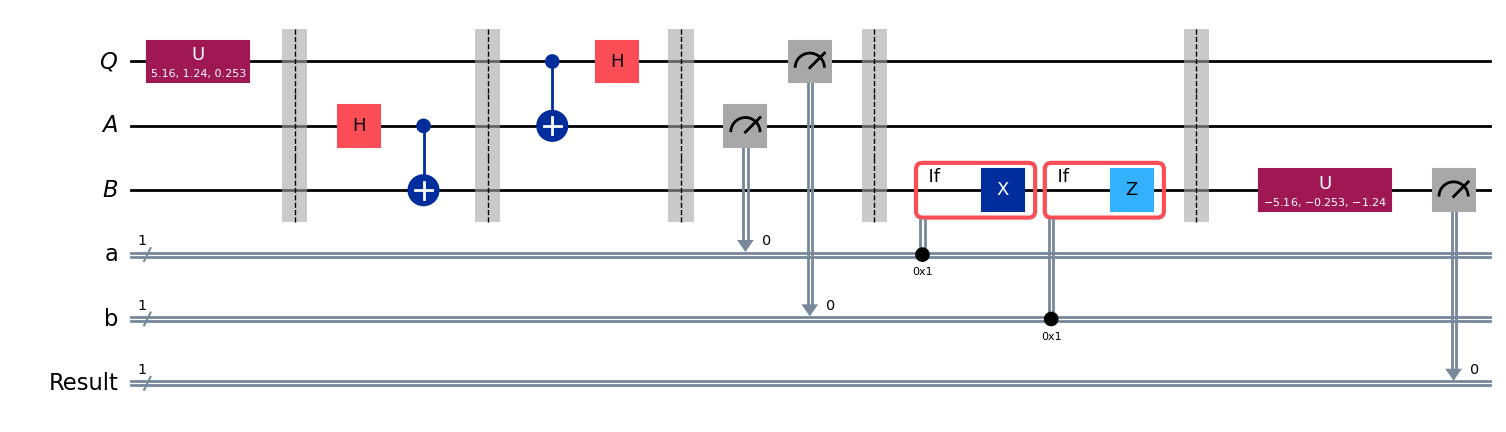

In [3]:
random_gate = UGate(
    theta=random.random() * 2 * pi,
    phi=random.random() * 2 * pi,
    lam=random.random() * 2 * pi
)

display(array_to_latex(random_gate.to_matrix()))

test = QuantumCircuit(qubit, ebit0, ebit1, a, b)
test.append(instruction=random_gate, qargs=[qubit])
test.barrier()

test.compose(protocol, inplace=True)
test.barrier()

test.append(random_gate.inverse(), ebit1)
result = ClassicalRegister(1, "Result")
test.add_register(result)
test.measure(ebit1, result)

display(test.draw(output="mpl"))

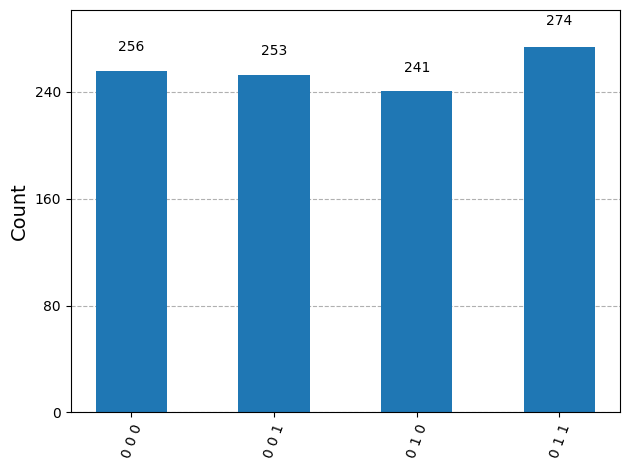

In [ ]:
# notice the bottom bit is always 0, indicating that Q is in the |0> state
result = AerSimulator().run(test).result()
statistics = result.get_counts()
display(plot_histogram(statistics))